# EXPPLORATORY DATA ANALYSIS

This notebook is used for data analysis for the images that were collected for the ecommerce fashion project for the 4th sem college project

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import seaborn as sns
from glob import glob
import os


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
folder_names=["/kaggle/input/datasets/afqwe0/clohtes/Himesh","/kaggle/input/datasets/afqwe0/clohtes/Mahesh","/kaggle/input/datasets/afqwe0/clohtes/Pratik","/kaggle/input/datasets/afqwe0/clohtes/Sworup"]

# **CLASS INDIFFERENCE**

In [3]:
prev_list=[]
classes=[]
dict_for_plt={}
for folder in folder_names:
    prev_list=os.listdir(folder)
    for files in prev_list:
        if not files== "Mahesh":
            classes.append(files)
            path=os.path.join(folder,files)
            dict_for_plt[files]=len(os.listdir(path))
    prev_list=[];
print(classes)
print(len(classes))
print(dict_for_plt)
print(len(dict_for_plt))

['fit-and-flare dress', 'denim shorts (jorts)', 'cowl neck top', 'turtle neck', 'cardigan', 'Dolphin shorts', 'skirt', 'Jacket', 'Dhaka Topi', 'Sari', 'men_suits_western_coatpant', 'Formal Pants Shirt Set', 'Loafers', 'Hoodie', 'Sneakers', 'T-Shirt', 'Trousers', 'Polo', 'Sweater', 'Blazer', 'Baggy Pants', 'Caps', 'One Piece', 'Sweat Shirt', 'Jeans Pants']
25
{'fit-and-flare dress': 108, 'denim shorts (jorts)': 128, 'cowl neck top': 111, 'turtle neck': 111, 'cardigan': 111, 'Dolphin shorts': 110, 'skirt': 158, 'Jacket': 111, 'Dhaka Topi': 102, 'Sari': 111, 'men_suits_western_coatpant': 306, 'Formal Pants Shirt Set': 131, 'Loafers': 137, 'Hoodie': 123, 'Sneakers': 100, 'T-Shirt': 101, 'Trousers': 99, 'Polo': 108, 'Sweater': 99, 'Blazer': 104, 'Baggy Pants': 101, 'Caps': 109, 'One Piece': 100, 'Sweat Shirt': 103, 'Jeans Pants': 116}
25


/tmp/ipykernel_16/3887131592.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=list(dict_for_plt.keys()),y=list(dict_for_plt.values()),palette='viridis')


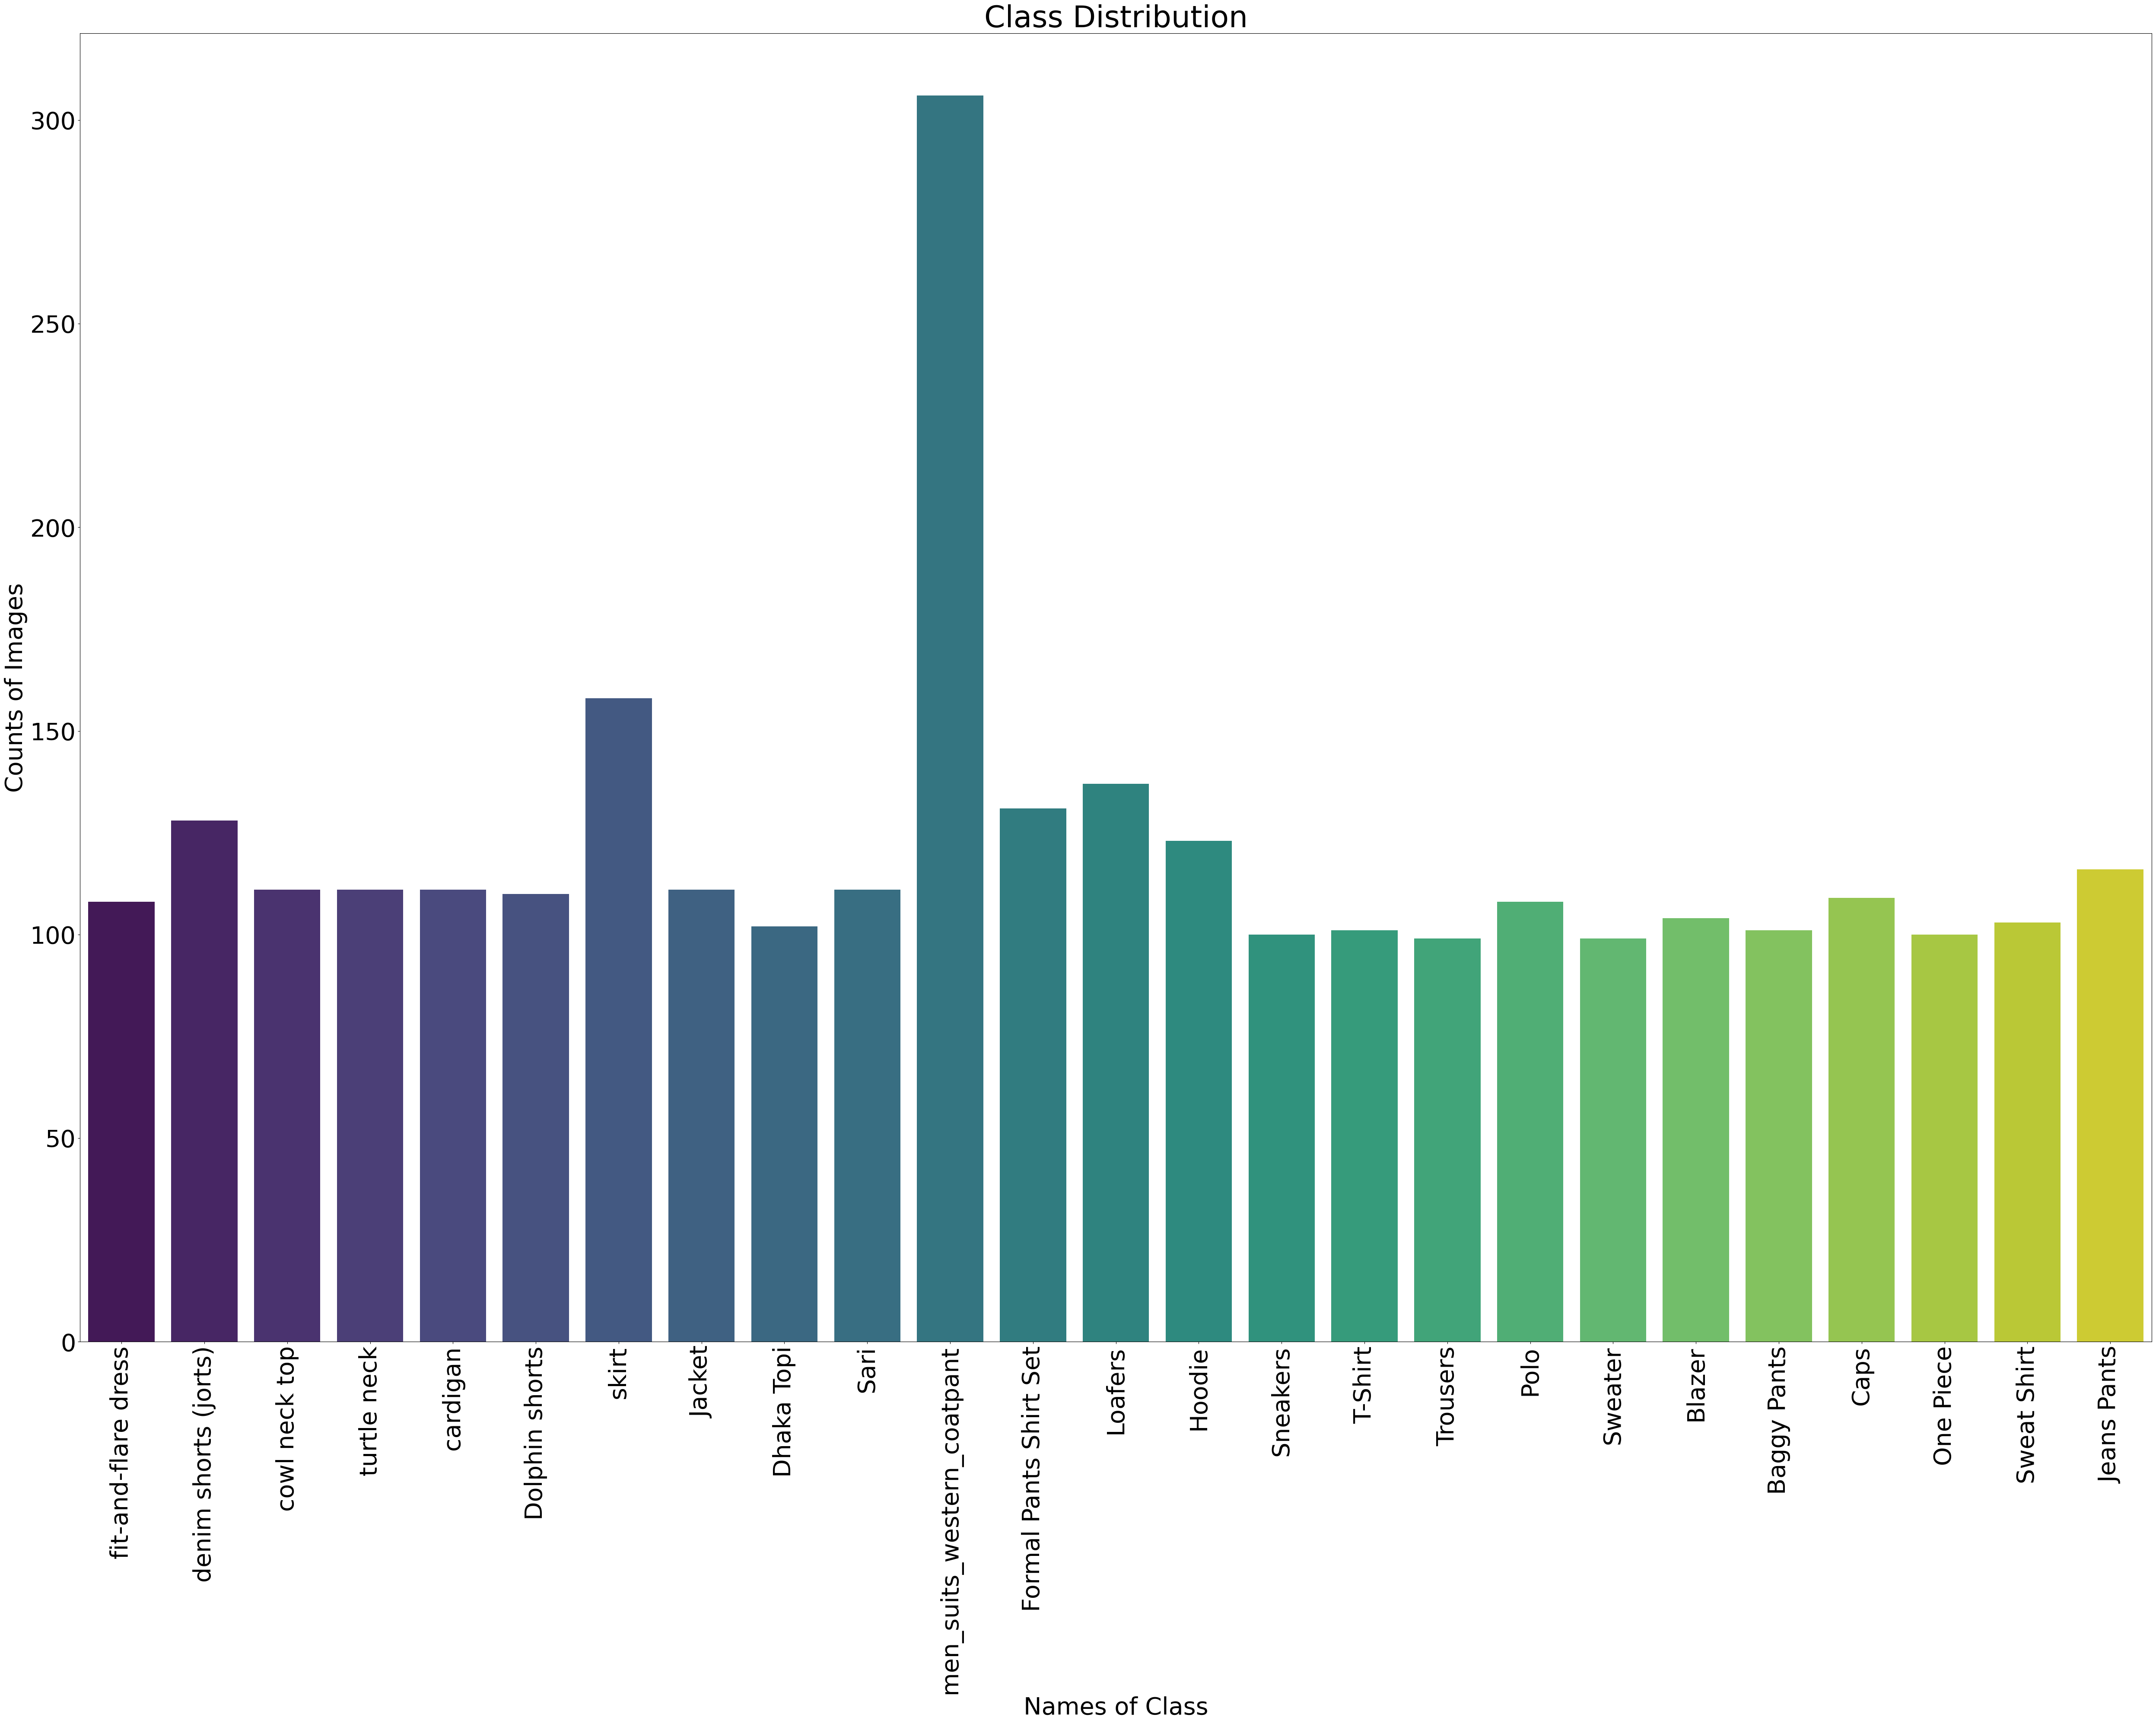

In [4]:
plt.figure(figsize=(50,40))
ax=sns.barplot(x=list(dict_for_plt.keys()),y=list(dict_for_plt.values()),palette='viridis')
plt.title("Class Distribution",fontsize=50)
plt.xlabel("Names of Class",fontsize=40)
plt.ylabel("Counts of Images",fontsize=40)
ax.tick_params(axis='x', labelsize=40, rotation=90)
ax.tick_params(axis='y', labelsize=40)

plt.tight_layout()
plt.show()


**This graph shows the class indifference between multiple classes in our data where men_suits have the most number of data whereas trousers and sweator have the lowest. The actual values would be as follows:**
*{'fit-and-flare dress': 108, 'denim shorts (jorts)': 128, 'cowl neck top': 111, 'turtle neck': 111, 'cardigan': 111, 'Dolphin shorts': 110, 'skirt': 158, 'Jacket': 111, 'Dhaka Topi': 102, 'Sari': 111, 'men_suits_western_coatpant': 306, 'Formal Pants Shirt Set': 131, 'Loafers': 137, 'Hoodie': 123, 'Sneakers': 100, 'T-Shirt': 101, 'Trousers': 99, 'Polo': 108, 'Sweater': 99, 'Blazer': 104, 'Baggy Pants': 101, 'Caps': 109, 'One Piece': 100, 'Sweat Shirt': 103, 'Jeans Pants': 116}*

# SIZE AND ASPECT RATIO

In [5]:
import os
from PIL import Image

sizes = []
total_height = 0
total_width = 0

for folder in folder_names:
    # Get all class subfolders inside this person's folder
    for class_name in os.listdir(folder):
        if class_name == "Mahesh":   # skip if you want
            continue
        
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        
        # Get image files
        image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
        
        # Sample first 50 images (or change to every 5th image)
        for idx, img_file in enumerate(image_files[:50]):   # first 50
            img_path = os.path.join(class_path, img_file)
            with Image.open(img_path) as img:
                width, height = img.size   # no parentheses
                total_width += width
                total_height += height
                sizes.append({
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height
                })
        avg_width = total_width / len(sizes)
        avg_height = total_height / len(sizes)

print(f"Collected {len(sizes)} images")

Collected 1250 images


In [6]:
print(f"Average size: {avg_width} x {avg_height}")
df_sizes=pd.DataFrame(sizes)
df_sizes[:500]

Average size: 766.2784 x 1049.216


,width,height,aspect_ratio
0,682,798,0.854637
1,790,1150,0.686957
2,766,788,0.972081
3,800,800,1.000000
4,468,832,0.562500
...,...,...,...
495,736,1308,0.562691
496,505,736,0.686141
497,736,857,0.858810
498,736,1039,0.708373


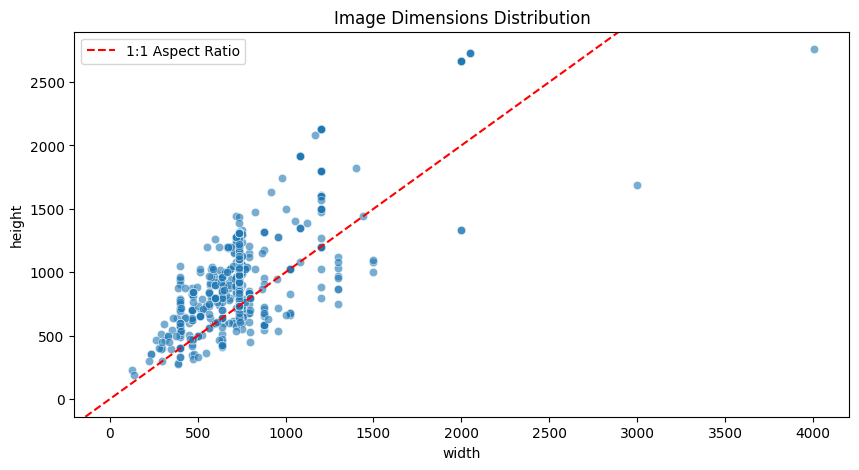

In [7]:
plt.figure(figsize=(10,5))
ax=sns.scatterplot(data=df_sizes,x="width",y="height",alpha=0.6)
plt.title("Image Dimensions Distribution")
plt.axline((0, 0), slope=1, color="red", linestyle="--", label="1:1 Aspect Ratio")
plt.legend()
plt.show()

# **BRIGHTNESS AND CONTRAST** 

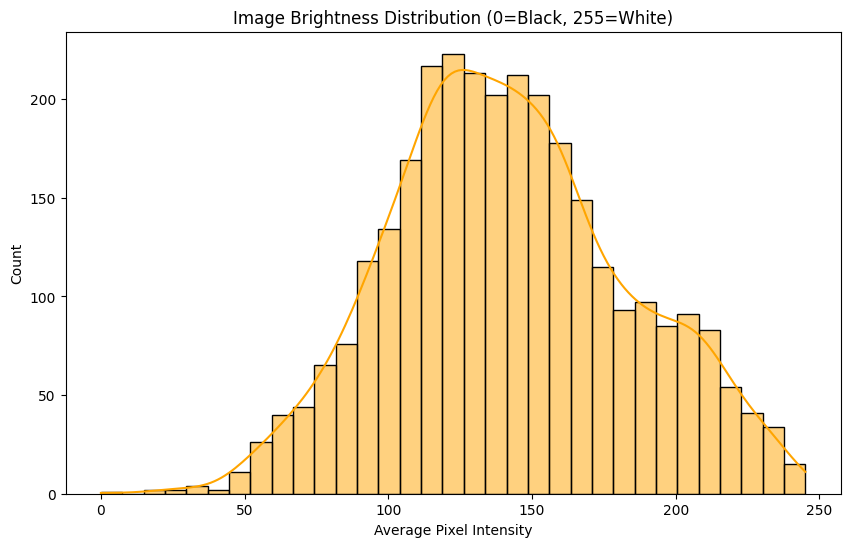

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rand
folder_names = [
    "/kaggle/input/datasets/afqwe0/clohtes/Himesh",
    "/kaggle/input/datasets/afqwe0/clohtes/Mahesh",
    "/kaggle/input/datasets/afqwe0/clohtes/Pratik",
    "/kaggle/input/datasets/afqwe0/clohtes/Sworup"
]

brightness = []
img_paths=[]
for folder in folder_names:
    if not os.path.exists(folder):
        continue
        
    # 1. Loop through class folders (e.g., T-Shirt, Jeans Pants)
    for class_folder in os.listdir(folder):
        if class_folder == "Mahesh" or class_folder.startswith('.'):
            continue
            
        class_path = os.path.join(folder, class_folder)
        
        if os.path.isdir(class_path):
            # 2. Loop through the actual images inside that class folder
            for img_name in os.listdir(class_path):
                if img_name.startswith('.'): 
                    continue
                
                # FIX: Build the absolute path to the image file
                img_path = os.path.join(class_path, img_name)
                if rand.randint(0,50)%2==0:
                    img_paths.append(img_path)
                # Read using the full path
                img_ = cv2.imread(img_path)
                
                # Verify OpenCV successfully loaded the image matrix
                if img_ is not None:
                    gray = cv2.cvtColor(img_, cv2.COLOR_BGR2GRAY)
                    brightness.append(np.mean(gray))
                else:
                    # This will alert you if an image file is actually broken/corrupted
                    print(f"Warning: Corrupted file or invalid format at {img_path}")

# Plot the results
plt.figure(figsize=(10, 6))
sns.histplot(data=brightness, kde=True, color="Orange")
plt.title("Image Brightness Distribution (0=Black, 255=White)")
plt.xlabel("Average Pixel Intensity")
plt.show()


# **COLOR CHANNEL ANALYSIS**

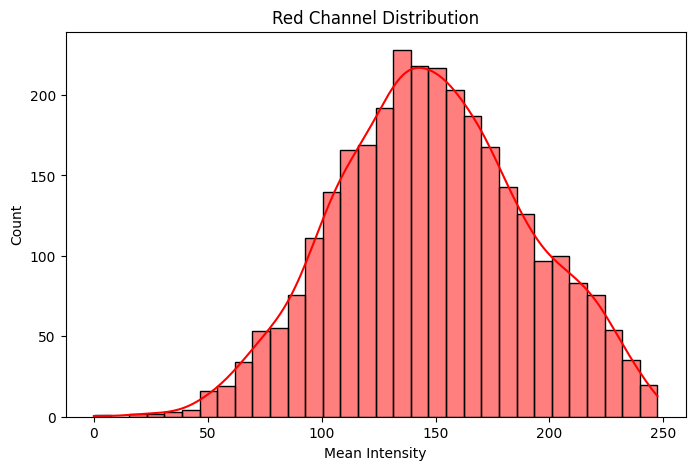

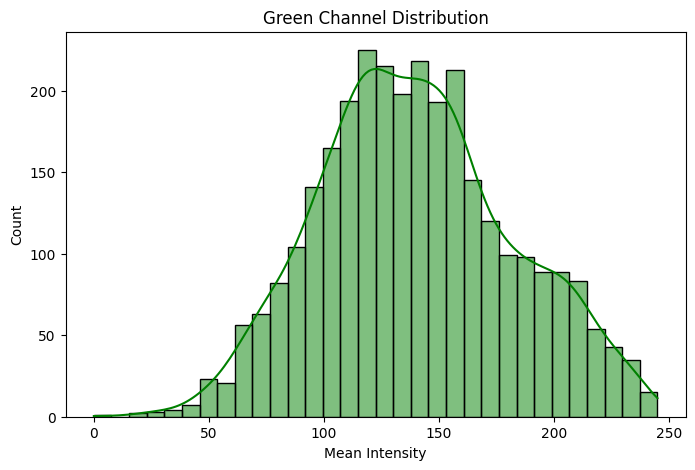

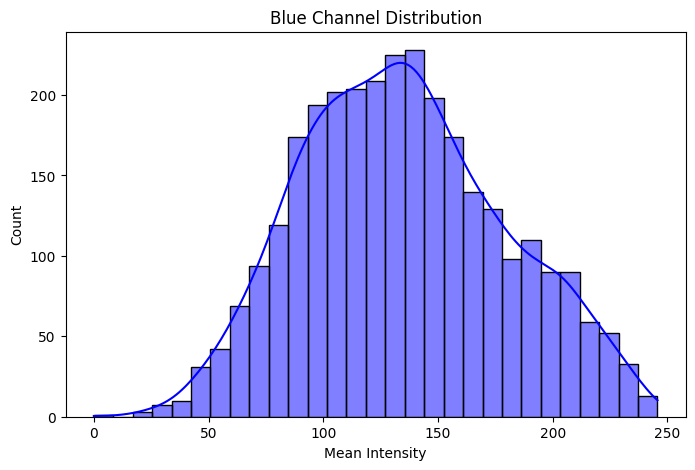

Average Red: 148.40409652394993
Average Green: 139.92576096652786
Average Blue: 134.7933870711751


In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = "/kaggle/input/datasets/afqwe0/clohtes"

red_means = []
green_means = []
blue_means = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.startswith('.'):
            continue

        img_path = os.path.join(root, file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        b, g, r = cv2.split(img)

        red_means.append(np.mean(r))
        green_means.append(np.mean(g))
        blue_means.append(np.mean(b))

# Red
plt.figure(figsize=(8,5))
sns.histplot(red_means, color='red', kde=True)
plt.title("Red Channel Distribution")
plt.xlabel("Mean Intensity")
plt.show()

# Green
plt.figure(figsize=(8,5))
sns.histplot(green_means, color='green', kde=True)
plt.title("Green Channel Distribution")
plt.xlabel("Mean Intensity")
plt.show()

# Blue
plt.figure(figsize=(8,5))
sns.histplot(blue_means, color='blue', kde=True)
plt.title("Blue Channel Distribution")
plt.xlabel("Mean Intensity")
plt.show()

print("Average Red:", np.mean(red_means))
print("Average Green:", np.mean(green_means))
print("Average Blue:", np.mean(blue_means))

# **RANDOM BATCHES OF DATA**

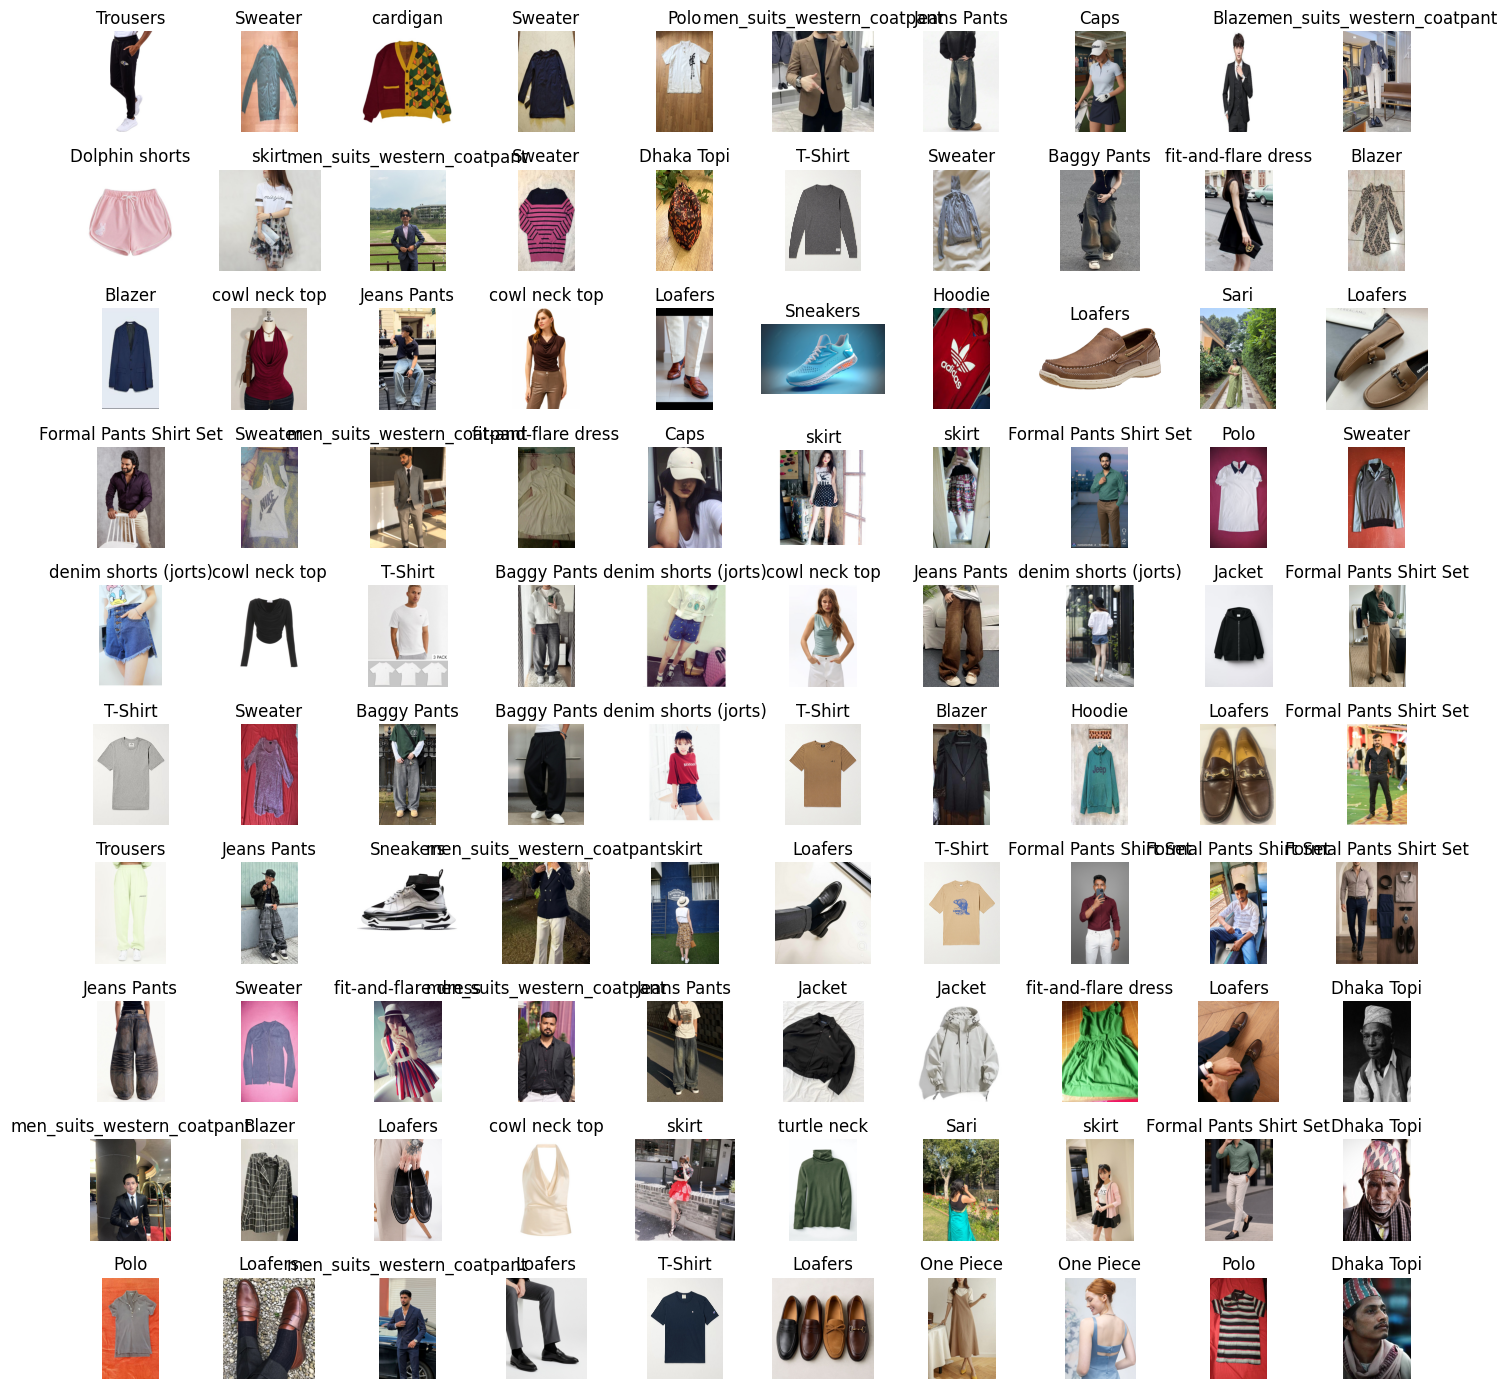

In [10]:
def plot_random_batch(image_paths, n_images=12):
    sample_paths = rand.sample(image_paths, n_images)
    
    plt.figure(figsize=(14, 14))
    for i, path in enumerate(sample_paths):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(10, 10, i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(os.path.dirname(path))) # Show class folder name
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_random_batch(img_paths,100)

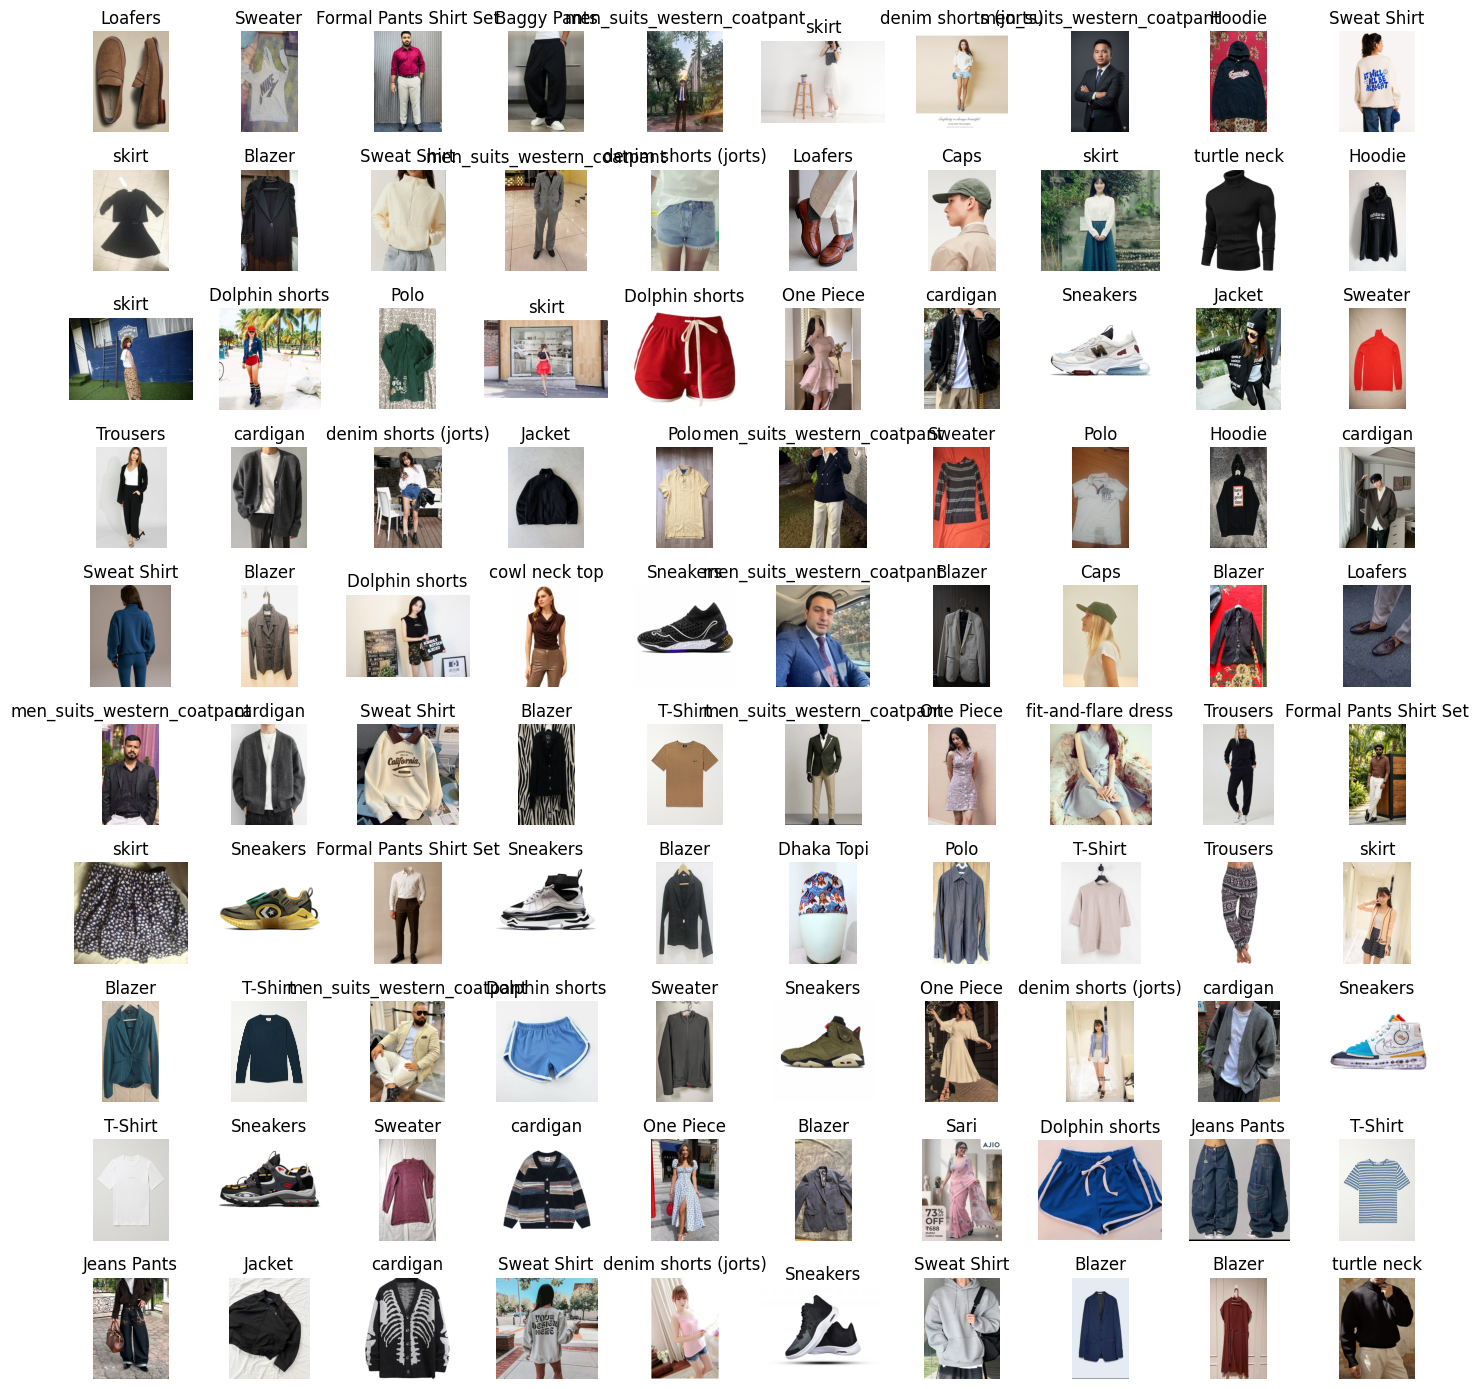

In [11]:
plot_random_batch(img_paths,100)

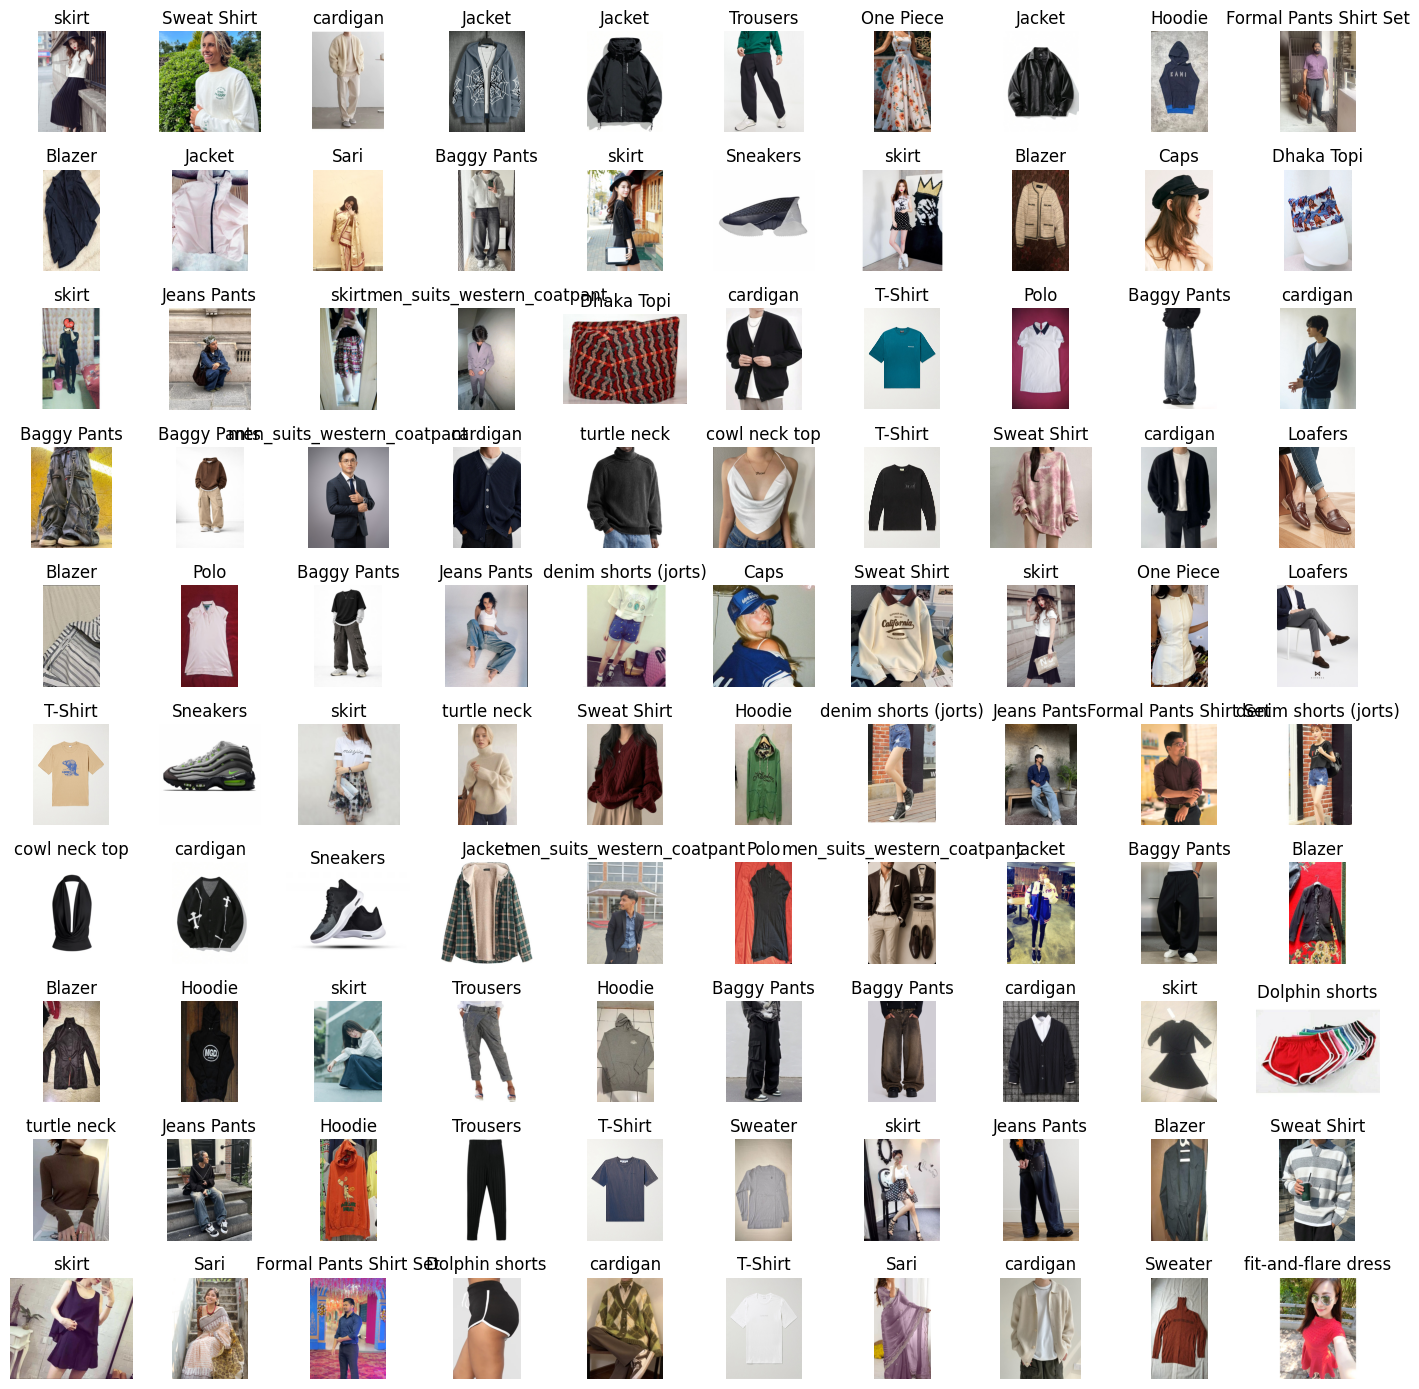

In [12]:
plot_random_batch(img_paths,100)